In [23]:
#  %pip install tensorly

Создадим тензор $\mathcal{A}$ из примера:

In [1]:
import tensorly as tl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
A = tl.tensor(np.array(np.arange(1, 9).reshape(2, 2, 2))).transpose(1, 2, 0)
print(A[:, :, 0])
print(A[:, :, 1])

[[1 2]
 [3 4]]
[[5 6]
 [7 8]]


Его развёртки:

In [3]:
print(tl.unfold(A, 0))
print(tl.unfold(A, 1))
print(tl.unfold(A, 2))

[[1 5 2 6]
 [3 7 4 8]]
[[1 5 3 7]
 [2 6 4 8]]
[[1 2 3 4]
 [5 6 7 8]]


Норма по Фробениусу:

In [4]:
print(tl.norm(A, 2))

14.2828568570857


Найдём приближённое CP ранга 1:

In [5]:
weights, factors = tl.decomposition.parafac(A, 1)
print("Полученные факторы:")
print(factors[0])
print(factors[1])
print(factors[2])
A_approx = np.zeros((2, 2, 2))
for i in range(2):
    for j in range(2):
        for k in range(2):
            A_approx[i, j, k] = factors[0][i] * factors[1][j] * factors[2][k]
print("Приближение ранга 1:")
print(A_approx)
print("Ошибка приближения:", tl.norm(A_approx - A)/tl.norm(A) * 100, "%")

Полученные факторы:
[[ 8.05549097]
 [11.72480302]]
[[0.6405734 ]
 [0.76789775]]
[[0.37594627]
 [0.9266415 ]]
Приближение ранга 1:
[[[1.93993283 4.78159361]
  [2.32552594 5.73201287]]

 [[2.82358088 6.95963081]
  [3.38481337 8.34297029]]]
Ошибка приближения: 8.960140221596793 %


C:\Users\vorkm\AppData\Local\Temp\ipykernel_18952\1371516502.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  A_approx[i, j, k] = factors[0][i] * factors[1][j] * factors[2][k]


Ранга 2:

In [6]:
r = 2
weights, factors = tl.decomposition.parafac(A, r)
print("Полученные факторы:", factors[0])
print(factors[1])
print(factors[2])
A_approx = np.zeros((2, 2, 2))
for i in range(2):
    for j in range(2):
        for k in range(2):
            for alpha in range(r):
                A_approx[i, j, k] += factors[0][i, alpha] * factors[1][j, alpha] * factors[2][k, alpha]
print(f"Приближение ранга {r}:")
print(A_approx)
print("Ошибка приближения:", tl.norm(A_approx - A)/tl.norm(A) * 100, "%")

Полученные факторы: [[ 9.03309667 -0.65645124]
 [11.48562411 -0.39770235]]
[[0.6699344  1.16019695]
 [0.75537973 0.91006058]]
[[0.60467955 3.52037183]
 [0.97315808 1.12836942]]
Приближение ранга 2:
[[[0.97810804 5.0297656 ]
  [2.02287469 5.96616486]]

 [[3.02843065 6.96743208]
  [3.97206486 8.03473255]]]
Ошибка приближения: 0.5811166770219353 %


Найдём левые сингулярные векторы развёрток, факторы $U, V, W$ и ядро $G$:

In [7]:
X_1 = tl.unfold(A, 0)
X_2 = tl.unfold(A, 1)
X_3 = tl.unfold(A, 2)
U, s1, _ = np.linalg.svd(X_1)
V, s2, _ = np.linalg.svd(X_2)
W, s3, _ = np.linalg.svd(X_3)
G = np.einsum("abc,ia,jb,kc->ijk", A, U.T, V.T, W.T)
print("U:", U)
print("V:", V)
print("W:", W)
print("G:", G)
A_restored = np.einsum("abc,ia,jb,kc->ijk", G, U, V, W)
print("Тензор, восстановленный из разложения:", A_restored)

U: [[-0.56672424 -0.82390754]
 [-0.82390754  0.56672424]]
V: [[-0.64142303 -0.7671874 ]
 [-0.7671874   0.64142303]]
W: [[-0.37616823 -0.92655138]
 [-0.92655138  0.37616823]]
G: [[[-1.42253953e+01  4.61793060e-03]
  [ 1.60125603e-02  5.43770692e-01]]

 [[ 8.28025332e-03  1.11585148e+00]
  [ 2.38589095e-01  2.00114739e-01]]]
Тензор, восстановленный из разложения: [[[1. 5.]
  [2. 6.]]

 [[3. 7.]
  [4. 8.]]]


Можно сделать то же самое с помощью библиотеки tensorly:

In [8]:
core, factors = tl.decomposition.tucker(A, rank=[2, 2, 2])
for i in range(3):
    print(f"Factor {i + 1}:", factors[i])
print("Core:", core)

Factor 1: [[ 0.56672424  0.82390754]
 [ 0.82390754 -0.56672424]]
Factor 2: [[ 0.64142303  0.7671874 ]
 [ 0.7671874  -0.64142303]]
Factor 3: [[ 0.37616823  0.92655138]
 [ 0.92655138 -0.37616823]]
Core: [[[ 1.42253953e+01 -4.61793060e-03]
  [-1.60125603e-02 -5.43770692e-01]]

 [[-8.28025332e-03 -1.11585148e+00]
  [-2.38589095e-01 -2.00114739e-01]]]


Реализуем простой алгоритм с Disjoint Components: посчитаем Tucker тензора, в каждой строчке факторов оставим только самое большое по модулю число и пересчитаем ядро по формуле $G=[[A; U^T, V^T, W^T]]$:

In [ ]:
from DisjointTuckerArgmax import DisjointTuckerArgmax

np.random.seed(42)
A = np.random.randn(6, 6, 6)
A[:3, :3, :3] += 2
A[3:, 3:, 3:] += 2

ranks = [2, 2, 2]
core_std, factors_std = tl.decomposition.tucker(A, rank=ranks)
A_approx = tl.tucker_to_tensor((core_std, factors_std))
print(f"Fit of Tucker3: {100-tl.norm(A-A_approx)/tl.norm(A) * 100}%")

disjoint_tucker = DisjointTuckerArgmax(ranks=ranks, disjoint_modes=[0, 1, 2])
core_dj, factors_dj = disjoint_tucker.fit_transform(A)
A_approx = tl.tucker_to_tensor((core_dj, factors_dj))
print(f"Fit of DisjointTucker, v1: {100-tl.norm(A-A_approx)/tl.norm(A) * 100}%")

Fit of Tucker3: 39.9098649842818%
Fit of DisjointTucker, v1: 38.40531872781299%


Text(0.5, 1.0, 'Factor 3, DisjointTucker (argmax)')

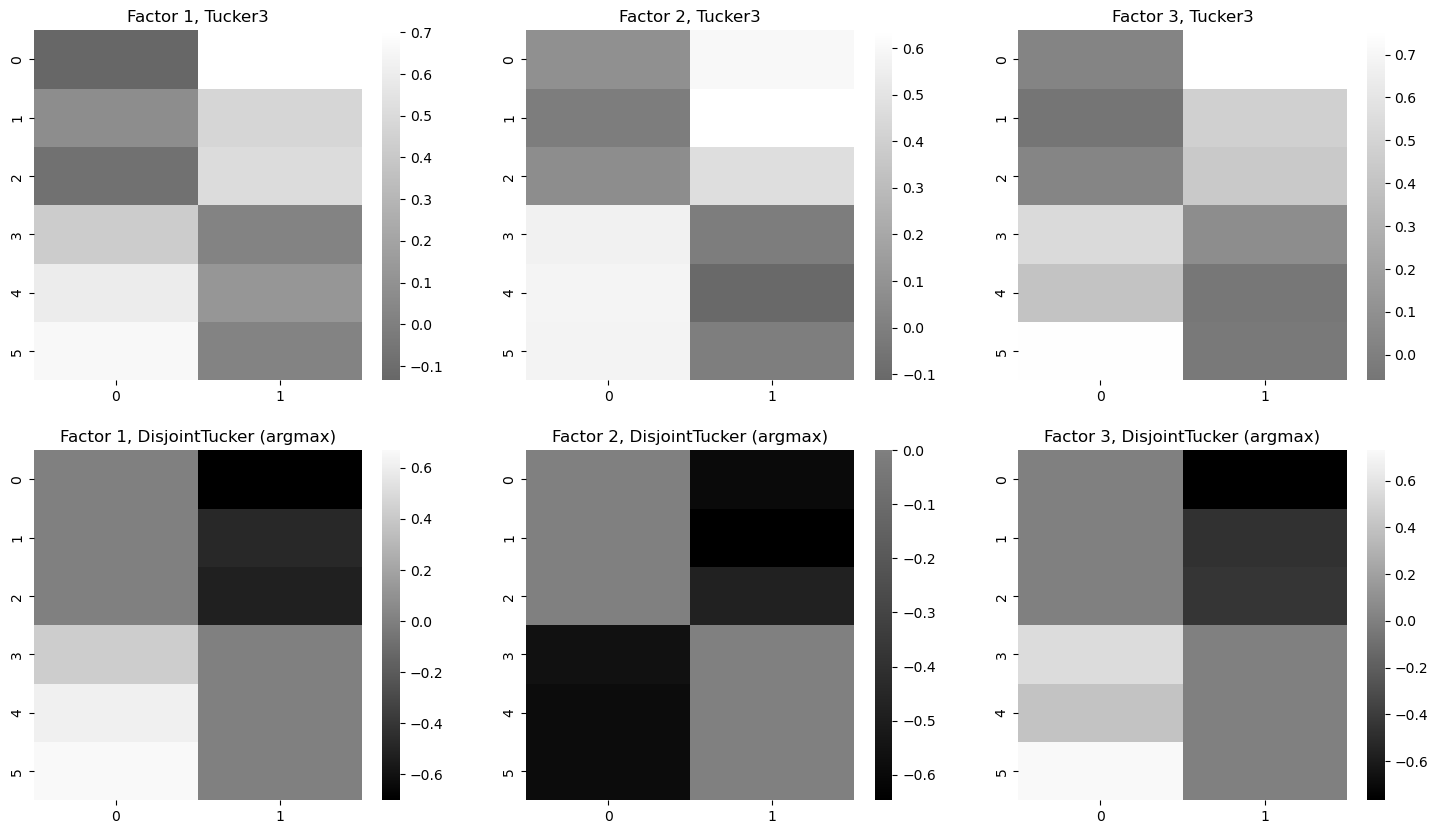

In [11]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
sns.heatmap(factors_std[0], cmap='grey', ax=axs[0, 0], center=0)
sns.heatmap(factors_std[1], cmap='grey', ax=axs[0, 1], center=0)
sns.heatmap(factors_std[2], cmap='grey', ax=axs[0, 2], center=0)
sns.heatmap(factors_dj[0], cmap='grey', ax=axs[1, 0], center=0)
sns.heatmap(factors_dj[1], cmap='grey', ax=axs[1, 1], center=0)
sns.heatmap(factors_dj[2], cmap='grey', ax=axs[1, 2], center=0)

axs[0, 0].set_title("Factor 1, Tucker3")
axs[0, 1].set_title("Factor 2, Tucker3")
axs[0, 2].set_title("Factor 3, Tucker3")

axs[1, 0].set_title("Factor 1, DisjointTucker (argmax)")
axs[1, 1].set_title("Factor 2, DisjointTucker (argmax)")
axs[1, 2].set_title("Factor 3, DisjointTucker (argmax)")

Попробуем тот же подход с Lasso Regression. Будем решать следующую задачу:
$$
    L(X, (G, Factors)) = ||X - [[G; Factors]]||^2_F + \alpha \sum_{F \in Factors} ||F||_{11} -> \min_{G, Factors}
$$
где 
$$
    ||F||_{11} = \sum_{i j} |f_{ij}|
$$
То есть сумма модулей всех элементов матрицы. Обычно решение данной задачи &mdash; разреженная матрица. Попробуем:

In [23]:
%load_ext autoreload
%autoreload 2

In [27]:
from DisjointTuckerLasso import DisjointTuckerLasso
np.random.seed(42)
A = np.random.randn(6, 6, 6)
A[:3, :3, :3] += 2
A[3:, 3:, 3:] += 2

ranks = [2, 2, 2]
random_state = 42
alpha=0.1

core_std, factors_std = tl.decomposition.tucker(A, rank=ranks, random_state=random_state)
fit_std = 100 * (1 - tl.norm(A - tl.tucker_to_tensor((core_std, factors_std))) / tl.norm(A))
print(f"Standard Tucker fit: {fit_std:.2f}%")

model = DisjointTuckerLasso(ranks=ranks, random_state=random_state, alpha=alpha)
core_dj, factors_dj = model.fit_transform(A)
fit_dj = 100 * (1 - tl.norm(A - tl.tucker_to_tensor((core_dj, factors_dj))) / tl.norm(A))
print(f"Disjoint Lasso Tucker fit: {fit_dj:.2f}%")

Standard Tucker fit: 39.91%
Disjoint Lasso Tucker fit: 24.28%


Text(0.5, 1.0, 'Factor 3, DisjointTucker (Lasso)')

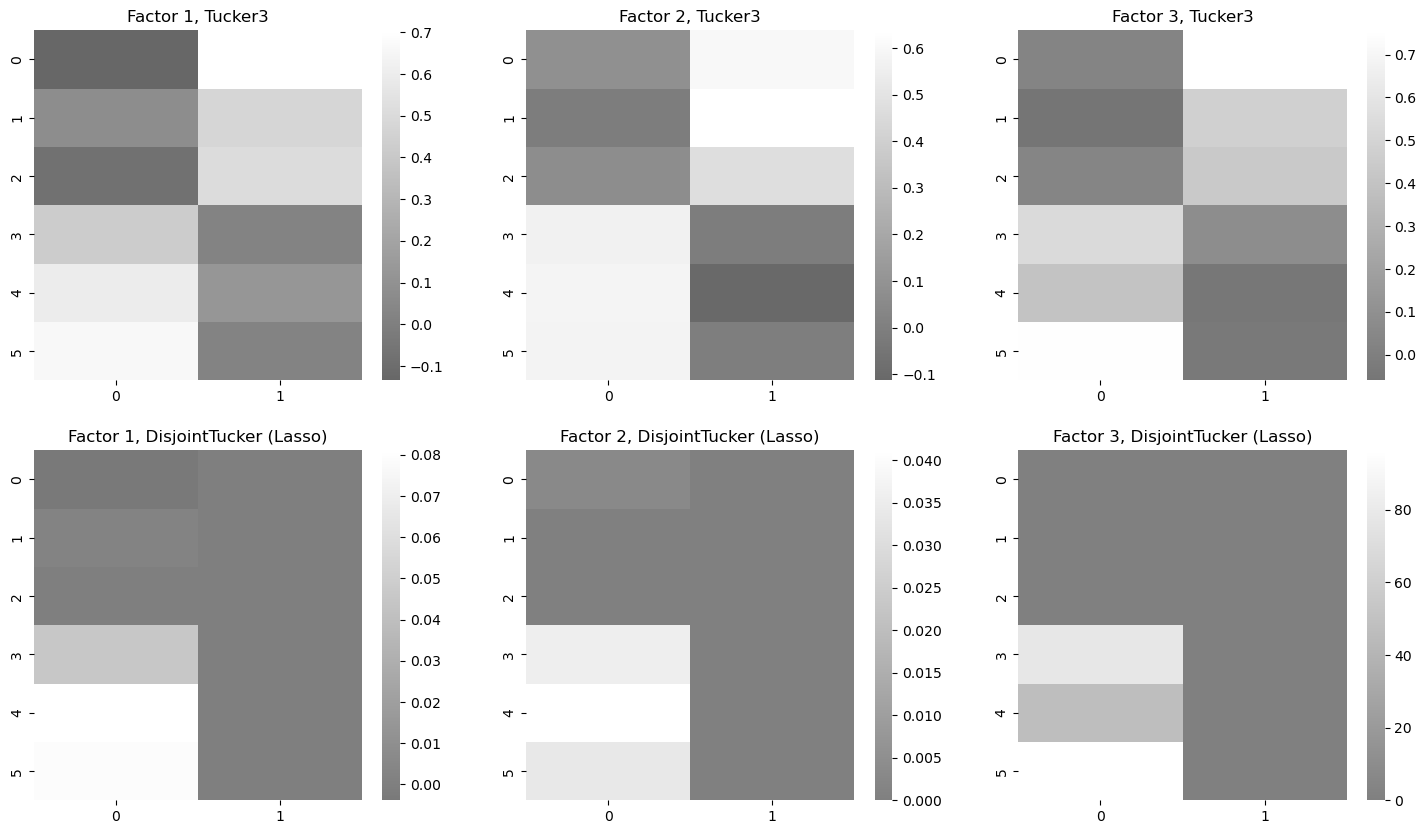

In [16]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
sns.heatmap(factors_std[0], cmap='grey', ax=axs[0, 0], center=0)
sns.heatmap(factors_std[1], cmap='grey', ax=axs[0, 1], center=0)
sns.heatmap(factors_std[2], cmap='grey', ax=axs[0, 2], center=0)
sns.heatmap(factors_dj[0], cmap='grey', ax=axs[1, 0], center=0)
sns.heatmap(factors_dj[1], cmap='grey', ax=axs[1, 1], center=0)
sns.heatmap(factors_dj[2], cmap='grey', ax=axs[1, 2], center=0)

axs[0, 0].set_title("Factor 1, Tucker3")
axs[0, 1].set_title("Factor 2, Tucker3")
axs[0, 2].set_title("Factor 3, Tucker3")

axs[1, 0].set_title("Factor 1, DisjointTucker (Lasso)")
axs[1, 1].set_title("Factor 2, DisjointTucker (Lasso)")
axs[1, 2].set_title("Factor 3, DisjointTucker (Lasso)")

Разложение "потеряло" один из кластеров.

In [43]:
from DisjointTucker import DisjointTucker

np.random.seed(42)
A = np.random.randn(6, 6, 6)
A[:3, :3, :3] += 2
A[3:, 3:, 3:] += 2

ranks = [2, 2, 2]
random_state = 42

core_std, factors_std = tl.decomposition.tucker(A, rank=ranks, random_state=random_state)
fit_std = 100 * (1 - tl.norm(A - tl.tucker_to_tensor((core_std, factors_std))) / tl.norm(A))
print(f"Standard Tucker fit: {fit_std:.2f}%")

model = DisjointTucker(ranks=ranks, disjoint_modes=[0, 1, 2], random_state=random_state)
core_dj, factors_dj = model.fit_transform(A)
fit_dj = 100 * (1 - tl.norm(A - tl.tucker_to_tensor((core_dj, factors_dj))) / tl.norm(A))
print(f"Disjoint Tucker fit: {fit_dj:.2f}%")

Standard Tucker fit: 39.91%
Disjoint Tucker fit: 37.95%


Text(0.5, 1.0, 'Factor 3, DisjointTucker')

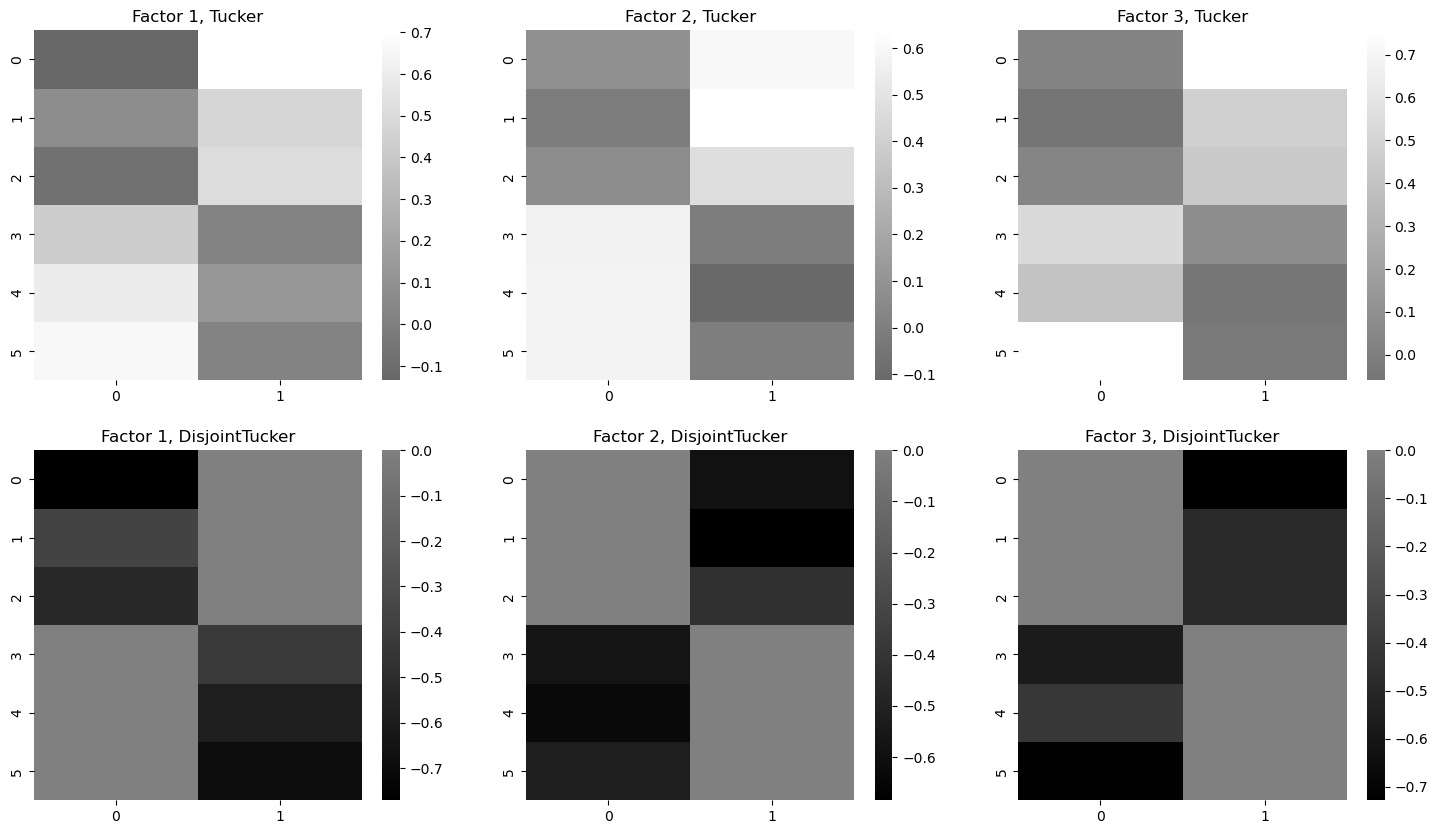

In [42]:
import seaborn as sns

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
sns.heatmap(factors_std[0], cmap='grey', ax=axs[0, 0], center=0)
sns.heatmap(factors_std[1], cmap='grey', ax=axs[0, 1], center=0)
sns.heatmap(factors_std[2], cmap='grey', ax=axs[0, 2], center=0)
sns.heatmap(factors_dj[0], cmap='grey', ax=axs[1, 0], center=0)
sns.heatmap(factors_dj[1], cmap='grey', ax=axs[1, 1], center=0)
sns.heatmap(factors_dj[2], cmap='grey', ax=axs[1, 2], center=0)

axs[0, 0].set_title("Factor 1, Tucker")
axs[0, 1].set_title("Factor 2, Tucker")
axs[0, 2].set_title("Factor 3, Tucker")

axs[1, 0].set_title("Factor 1, DisjointTucker")
axs[1, 1].set_title("Factor 2, DisjointTucker")
axs[1, 2].set_title("Factor 3, DisjointTucker")

По полученным disjoint factors можно отследить, какому кластеру принадлежит каждая строчка в соответствующей моде.